## MethodOfSimulatedMoments.jl and Surrogates.jl (parallel)

This notebook shows how one can estimate a model using [MethodOfSimulatedMoments.jl](https://github.com/JulienPascal/MethodOfSimulatedMoments.jl) and [Surrogates.jl](https://github.com/SciML/Surrogates.jl), evaluating the objective function **in parallel** on several workers:

1. the points of the initial design are evaluated in parallel (`pmap`);
2. the surrogate optimization proceeds by **batches**: at each iteration, `potential_optimal_points` proposes one new point per worker (with the SRBF method, see the [Surrogates.jl documentation](https://docs.sciml.ai/Surrogates/stable/parallel/#Parallel-Optimization)), and the batch is evaluated in parallel;
3. the local refinement runs one local minimization per worker (`msm_multistart!`).

Parallel evaluations pay off when one evaluation of the objective function is expensive. The linear model below is cheap, so the notebook adds an artificial cost to each evaluation (`modelCost`), to illustrate the speed-up. Set it to `0.0` to disable it.

In [1]:
using ClusterManagers
using Distributed

OnCluster = false #set to false to run locally
addWorkers = true #set to false to run serially
println("OnCluster = $(OnCluster)")

# Current number of workers
#--------------------------
currentWorkers = nworkers()
println("Initial number of workers = $(currentWorkers)")

# Increase the number of workers available
#-----------------------------------------
maxNumberWorkers = 10
if addWorkers == true
	if OnCluster == true
	  addprocs(SlurmManager(maxNumberWorkers))
	else
	  addprocs(maxNumberWorkers)
	end
end


# Sanity checks
#-------------
hosts = []
pids = []
for i in workers()
	host, pid = fetch(@spawnat i (gethostname(), getpid()))
	println("Hello I am worker $(i)")
	push!(hosts, host)
	push!(pids, pid)
end

currentWorkers = nworkers()
println("Number of workers = $(currentWorkers)")

OnCluster = false
Initial number of workers = 1
Hello I am worker 2
Hello I am worker 3
Hello I am worker 4
Hello I am worker 5
Hello I am worker 6
Hello I am worker 7
Hello I am worker 8
Hello I am worker 9
Hello I am worker 10
Hello I am worker 11
Number of workers = 10


Initial number of workers = 1


Hello I am worker 2


Hello I am worker 3


Hello I am worker 4


...

Hello I am worker 7


Hello I am worker 8


Hello I am worker 9


Hello I am worker 10


Hello I am worker 11
Number of workers = 10


In [2]:
using Plots
using ParallelDataTransfer
using DataFrames
using RobustPmap #Necessary for AffineInvariantMCMC
using CSV
@everywhere using MethodOfSimulatedMoments
@everywhere using Optim
@everywhere using Surrogates
@everywhere using OrderedCollections
@everywhere using Distributions
@everywhere using Random
@everywhere using Statistics
@everywhere using LinearAlgebra

True intercept = 0.21858665481883066
True coefficient beta0 = [0.32597672886359486, 0.5490511363155669]
Serial correlation coefficient theta0 = 0.0


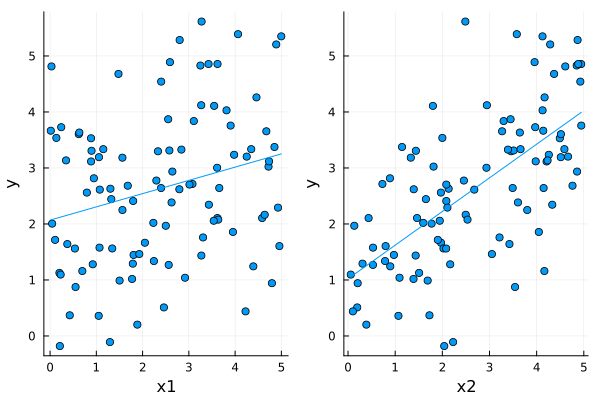

In [3]:
# Generate simulated data
Random.seed!(1234)  #for replicability reasons
T = 10000          #number of periods
P = 2               #number of independent variables

#beta0 = rand(P)     #choose true coefficients by drawing from a uniform distribution on [0,1]
#alpha0 = rand(1)[]  #intercept

theta0 = 0.0        #coefficient to create serial correlation in the error terms
beta0 = rand(P)
alpha0 = rand(1)[] 

println("True intercept = $(alpha0)")
println("True coefficient beta0 = $(beta0)")
println("Serial correlation coefficient theta0 = $(theta0)")
true_vals = [alpha0, beta0[1], beta0[2]]

# Generation of error terms
# row = individual dimension
# column = time dimension 
U = zeros(T)
d = Normal()
U[1] = rand(d, 1)[] #first error term
# loop over time periods
for t = 2:T
    U[t] = rand(d, 1)[] + theta0*U[t-1]
end

# Let's simulate the independent variables x_t
x = zeros(T, P)

d = Uniform(0, 5)
for p = 1:P  
    x[:,p] = rand(d, T)
end

# Let's calculate the resulting y_t
y = zeros(T)

for t=1:T
    y[t] = alpha0 + x[t,1]*beta0[1] + x[t,2]*beta0[2] + U[t]
end

# Send simulated data to workers
sendto(workers(), y=y)
sendto(workers(), x=x)

# Visualize data
p1 = scatter(x[1:100,1], y[1:100], xlabel = "x1", ylabel = "y", legend=:none, smooth=true)
p2 = scatter(x[1:100,2], y[1:100], xlabel = "x2", ylabel = "y", legend=:none, smooth=true)
plot(p1, p2)

In [4]:
# Define locally
# (finite penaltyValue: in the section "Handling failures", the baseline feeds the penalty value of failed
# evaluations to the surrogate, which requires a finite value; MethodOfSimulatedMoments.jl's default is Inf)
myProblem = MSMProblem(options = MSMOptions(maxFuncEvals=1000, globalOptimizer = :dxnes, localOptimizer = :NelderMead, penaltyValue = 999999.0));

# Send to workers
sendto(workers(), myProblem=myProblem)

# Priors
dictPriors = OrderedDict{String,Array{Float64,1}}()
dictPriors["alpha"] = [0.5, 0.001, 1.0]
dictPriors["beta1"] = [0.5, 0.001, 1.0]
dictPriors["beta2"] = [0.5, 0.001, 1.0]

# Empirical moments
dictEmpiricalMoments = OrderedDict{String,Array{Float64,1}}()
dictEmpiricalMoments["mean"] = [mean(y)] #informative on the intercept
dictEmpiricalMoments["mean^2"] = [mean(y.^2)] #informative on the intercept
dictEmpiricalMoments["mean_x1y"] = [mean(x[:,1] .* y)] #informative on betas
dictEmpiricalMoments["mean_x2y"] = [mean(x[:,2] .* y)] #informative on betas
dictEmpiricalMoments["mean_x1y^2"] = [mean((x[:,1] .* y).^2)] #informative on betas
dictEmpiricalMoments["mean_x2y^2"] = [mean((x[:,2] .* y).^2)] #informative on betas

W = Matrix(1.0 .* I(length(dictEmpiricalMoments)))#initialization
#Special case: diagonal matrix
#Sum of square percentage deviations from empirical moments
#(you may choose something else)
for (indexMoment, k) in enumerate(keys(dictEmpiricalMoments))
    W[indexMoment,indexMoment] = 1.0/(dictEmpiricalMoments[k][1])^2
end

# Send to workers
sendto(workers(), dictPriors=dictPriors)
sendto(workers(), dictEmpiricalMoments=dictEmpiricalMoments)
sendto(workers(), W=W)

@everywhere set_priors!(myProblem, dictPriors)
@everywhere set_empirical_moments!(myProblem, dictEmpiricalMoments)
@everywhere set_weight_matrix!(myProblem, W)

In [5]:
# x[1] corresponds to the intercept, x[2] corresponds to beta1, x[3] corresponds to beta2
# Optimized function compared to other notebooks: much less memory allocations and gaussian draws pre-computed
@everywhere function functionLinearModel(x; gaussian_draws::Array{Float64,1}, simX::Array{Float64,2}, nbDraws::Int64 = length(gaussian_draws), burnInPerc::Int64 = 0)
    # gaussian_draws: N(0,1) draws, computed once outside of this function (frozen draws)
    alpha, beta1, beta2 = x[1], x[2], x[3]
    theta = 0.0     #coefficient to create serial correlation in the error terms

    # Get rid of the burn-in phase: moments use periods startT, ..., nbDraws
    #-----------------------------------------------------------------------
    startT = max(1, floor(Int, nbDraws * burnInPerc / 100))

    # One pass over the simulated periods: running sums, no temporary arrays
    #-----------------------------------------------------------------------
    s_y = s_y2 = s_x1y = s_x2y = s_x1y2 = s_x2y2 = 0.0
    U = 0.0
    @inbounds for t in 1:nbDraws
        U = gaussian_draws[t] + theta*U     #error term: U[1] = draw[1], U[t] = draw[t] + theta*U[t-1]
        y = alpha + simX[t,1]*beta1 + simX[t,2]*beta2 + U
        if t >= startT
            x1y = simX[t,1]*y
            x2y = simX[t,2]*y
            s_y += y
            s_y2 += y^2
            s_x1y += x1y
            s_x2y += x2y
            s_x1y2 += x1y^2
            s_x2y2 += x2y^2
        end
    end

    # Moments:
    #---------
    n = nbDraws - startT + 1
    output = OrderedDict{String,Float64}()
    output["mean"] = s_y/n
    output["mean^2"] = s_y2/n
    output["mean_x1y"] = s_x1y/n
    output["mean_x2y"] = s_x2y/n
    output["mean_x1y^2"] = s_x1y2/n
    output["mean_x2y^2"] = s_x2y2/n

    return output
end


In [6]:
# Let's freeze the randomness during the minimization
d_Uni = Uniform(0,1)
nbDraws = T #Number of draws in the simulated data
burnInPerc = 0 #Burn-in phase. Not necessary in the present context.
startT = max(1, floor(Int, nbDraws * burnInPerc / 100)) #First period used to calculate moments on simulated data
NMSM = nbDraws - startT + 1; #Number of Draws used when calculated moments on simulated data
tau = T/NMSM #ratio of the sizes of the empirical and simulated samples (simulation noise)
uniform_draws = rand(d_Uni, nbDraws)
gaussian_draws = quantile.(Normal(), uniform_draws) #inverse transform sampling, once (the draws are frozen)
simX = zeros(length(uniform_draws), 2)
d = Uniform(0, 5)
for p = 1:2
  simX[:,p] = rand(d, length(uniform_draws))
end

# Send to workers
sendto(workers(), burnInPerc=burnInPerc)
sendto(workers(), simX=simX)
sendto(workers(), gaussian_draws=gaussian_draws)

# Construct the objective function everywhere
@everywhere set_simulate_empirical_moments!(myProblem, x -> functionLinearModel(x, gaussian_draws = gaussian_draws, simX = simX, burnInPerc=burnInPerc))
@everywhere construct_objective_function!(myProblem)

In [7]:
# Safety check: value on the master node == values on slave nodes?
using Test
val_local = myProblem.objective_function(ones(3)); #local execution
val_workers = [];
for w in workers() #Execution on workers
    push!(val_workers, @fetchfrom w myProblem.objective_function(ones(3)))
end
for (wIndex, w) in enumerate(workers())
    @test abs(val_local - val_workers[wIndex]) < 10e-10
end

### Sampling

In [8]:
n_samples = 100
lower_bound = create_lower_bound(myProblem)
upper_bound = create_upper_bound(myProblem)
xys = Surrogates.sample(n_samples, lower_bound, upper_bound, SobolSample());
size(xys)

(100,)

In [9]:
# Objective function as a named function defined on every process: each worker uses
# its own copy of myProblem (see MSM-MCMC.ipynb)
@everywhere objective(x) = myProblem.objective_function(collect(x))
g(x) = myProblem.objective_function(x) #used by the plots below

# Mimic an expensive model: each evaluation waits modelCost seconds (0.0 to disable)
modelCost = 0.0
@everywhere modelCost = $modelCost

# The surrogate models log(objective function): the objective function spans several orders
# of magnitude, and its logarithm is much easier to approximate (the objective function is > 0)
@everywhere log_objective(x) = (sleep(modelCost); log(objective(x)))

# Initial design: the n_samples evaluations are independent, so they can run in parallel
t_serial = @elapsed map(log_objective, xys)
t_parallel = @elapsed (zs = pmap(log_objective, xys))
println("$(length(xys)) evaluations: serial $(round(t_serial, digits = 2)) s, parallel on $(nworkers()) worker(s) $(round(t_parallel, digits = 2)) s")

100 evaluations: serial 0.17 s, parallel on 10 worker(s) 1.9 s


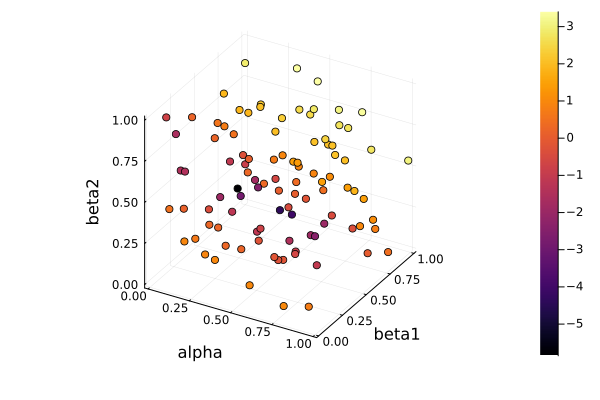

In [10]:
# Sample points in the parameter space, colored by log(objective function)
# (zs, computed above, must not be overwritten: it is used to build the surrogate)
alphas = [xy[1] for xy in xys]
beta1s = [xy[2] for xy in xys]
beta2s = [xy[3] for xy in xys]
scatter(alphas, beta1s, beta2s, zcolor=zs, xlabel="alpha", ylabel="beta1", zlabel="beta2", label="")

### Building a surrogate

The rest of the notebook works with any surrogate of [Surrogates.jl](https://docs.sciml.ai/Surrogates/stable/) that supports `update!`: it only evaluates the surrogate, reads the evaluated points (`surrogate.x`) and values (`surrogate.y`), and adds new points with `update!`. Choose the surrogate with `surrogateType`, and the method proposing new points with `method`:

* `surrogateType = :Kriging` (default): Kriging with smoothness `p = 1.5`. With Surrogates.jl 7.5.5, the correlation scale `theta` is not fitted to the data (more recent versions fit it by maximum likelihood).
* `surrogateType = :RadialBasis`: cubic radial basis function (`rad = cubicRadial()`). It has no hyperparameters to fit. (With Surrogates.jl 7.5.5, `thinplateRadial()` fails with points stored as tuples.)
* `method = EI()` (default): expected improvement. It needs the uncertainty of the surrogate (`std_error_at_point`), available with `Kriging` but **not** with `RadialBasis`.
* `method = SRBF()`: stochastic radial basis function method; works with any surrogate, including `RadialBasis`.

Both surrogates model log(objective function). To use another surrogate, add a branch below.

In [11]:
# Surrogate of log(objective function), and method proposing new points
#----------------------------------------------------------------------
surrogateType = :RadialBasis   # :Kriging or :RadialBasis
method = SRBF()              # EI() (needs the uncertainty of the surrogate) or SRBF() (any surrogate)

if surrogateType == :RadialBasis
    surrogate = RadialBasis(xys, zs, lower_bound, upper_bound, rad = cubicRadial())
elseif surrogateType == :Kriging
    surrogate = Kriging(xys, zs, lower_bound, upper_bound, p = collect([1.5 for k in 1:length(dictPriors)]))
else
    error("surrogateType must be :RadialBasis or :Kriging")
end

# EI() needs the uncertainty of the surrogate
if method isa EI && !hasmethod(std_error_at_point, Tuple{typeof(surrogate), eltype(surrogate.x)})
    error("EI() needs a surrogate with uncertainty estimates (e.g. Kriging): use method = SRBF() with $(nameof(typeof(surrogate)))")
end
println("Surrogate: $(nameof(typeof(surrogate))), built on $(length(surrogate.x)) points; method: $(nameof(typeof(method)))")

Surrogate: RadialBasis, built on 100 points; method: SRBF


### Optimizing, by batches evaluated in parallel

At each iteration, `potential_optimal_points` proposes `batchSize` new points with the **SRBF** method (stochastic radial basis function): candidate points are drawn around the best point found so far, and the one with the best compromise between a low value of the surrogate and a large distance to the points already evaluated is selected.

The next points of the batch are selected after pretending that the previous ones have been evaluated at the mean of the observed values (`MeanConstantLiar()`), so that the batch spreads out instead of repeating the same point. T

The batch is evaluated in parallel with `pmap`, and added to the surrogate with `update!`. The candidate points are drawn with `RandomSample()`. The loop runs `maxBatches` batches: improvements of the best point are sporadic, so stopping after a few batches without improvement would stop too early.


In [12]:
# Live history plot: redrawn during the minimization, after each batch
#----------------------------------------------------------------------
# The batches are proposed on the master process, and pmap returns their values to it: the
# master knows the full history after each batch, and redraws the figure (nothing to do on the workers).
function plot_history(samples, objectiveValues, nInitial; paramNames, lower, upper, trueValues = nothing,
                      successes = trues(length(objectiveValues)), nbEvaluations = length(objectiveValues), title = "")

    colorInitial = "#a8a7a2"                        # neutral gray: initial design
    colorFailure = "#eb6834"                        # orange: failures
    colorBest    = all(successes) ? "#eb6834" : :black    # best so far (black when orange shows the failures)
    rampAdded    = cgrad(["#86b6ef", "#104281"])    # one hue (blue): light = early, dark = late

    n = length(objectiveValues)
    xLimits = (0, max(nbEvaluations, n) + 1)

    # Best successful point so far (index 0 before the first success)
    bestIndex = zeros(Int, n)
    iBest = 0
    for t in 1:n
        if successes[t] && (iBest == 0 || objectiveValues[t] < objectiveValues[iBest])
            iBest = t
        end
        bestIndex[t] = iBest
    end
    bestSoFar = [k == 0 ? NaN : objectiveValues[k] for k in bestIndex]

    initialOK = [t for t in 1:min(nInitial, n) if successes[t]]
    addedOK = [t for t in (nInitial + 1):n if successes[t]]
    failures = [t for t in 1:n if !successes[t]]

    # (1) Objective function at each evaluation (log scale)
    p_conv = plot(yscale = :log10, xlims = xLimits, xlabel = "evaluation", ylabel = "objective function (log scale)",
                  title = title, titlefontsize = 11, legend = :topright, legendfontsize = 8, gridalpha = 0.3,
                  left_margin = 8Plots.mm, bottom_margin = 4Plots.mm)
    if !isempty(initialOK)
        scatter!(p_conv, initialOK, objectiveValues[initialOK], color = colorInitial, markersize = 4,
                 markerstrokewidth = 0, label = "initial design")
    end
    if !isempty(addedOK)
        scatter!(p_conv, addedOK, objectiveValues[addedOK], marker_z = addedOK, color = rampAdded, colorbar = false,
                 markersize = 4, markerstrokewidth = 0, label = "batches (light = early, dark = late)")
    end
    if !isempty(failures) && iBest != 0
        failureLevel = 3 * maximum(objectiveValues[successes])
        scatter!(p_conv, failures, fill(failureLevel, length(failures)), color = colorFailure, marker = :utriangle,
                 markersize = 5, markerstrokewidth = 0, label = "failure")
    end
    plot!(p_conv, 1:n, bestSoFar, seriestype = :steppost, color = colorBest, linewidth = 2, label = "best so far")

    # (2) Value of each parameter at the best point so far
    panels = []
    for i in eachindex(paramNames)
        trace = [k == 0 ? NaN : samples[k][i] for k in bestIndex]
        p = plot(1:n, trace, seriestype = :steppost, color = colorBest, linewidth = 2, xlims = xLimits,
                 ylims = (lower[i], upper[i]), xlabel = "evaluation", ylabel = paramNames[i],
                 title = iBest == 0 ? "" : "$(paramNames[i]) = $(round(samples[iBest][i], sigdigits = 4))",
                 titlefontsize = 9, gridalpha = 0.3, legend = false, left_margin = 6Plots.mm)
        if trueValues !== nothing
            hline!(p, [trueValues[i]], color = :black, linestyle = :dash, linewidth = 1)
        end
        push!(panels, p)
    end
    p_params = plot(panels..., layout = (1, length(panels)))

    return plot(p_conv, p_params, layout = Plots.grid(2, 1, heights = [0.6, 0.4]), size = (1000, 650))

end

# Display the figure. In Jupyter, it replaces the previous one (clear_output(true) waits for the
# new figure before clearing: no flicker). Everything displayed earlier in the cell is also cleared.
function show_live(fig)
    if isdefined(Main, :IJulia) && Main.IJulia.inited
        Main.IJulia.clear_output(true)
    end
    display(fig)
end

show_live (generic function with 1 method)

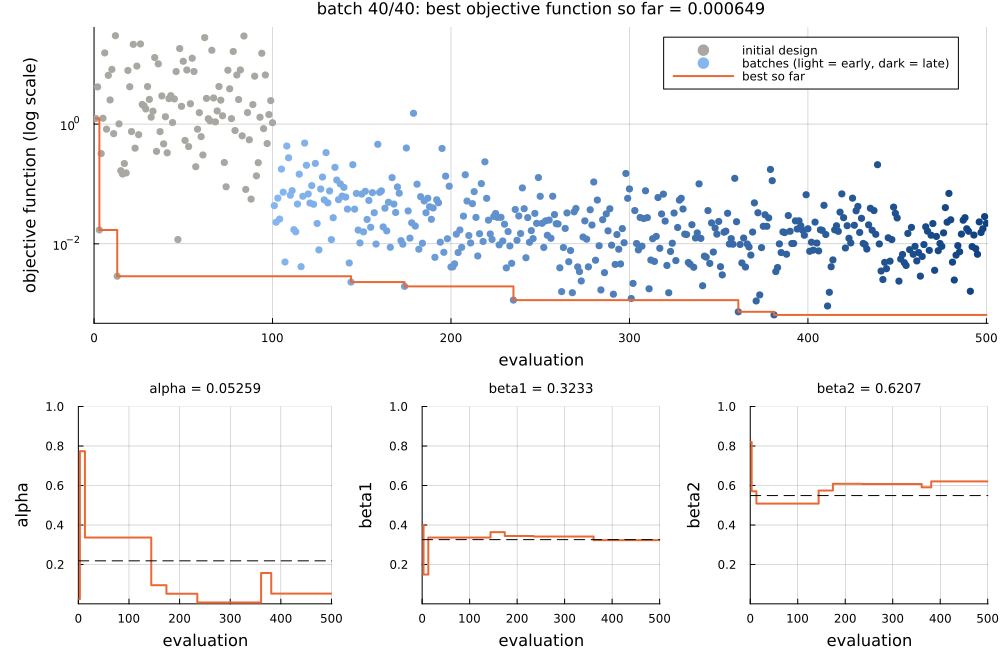

 15.079169 seconds (36.78 M allocations: 2.417 GiB, 8.60% gc time, 280 lock conflicts, 38.59% compilation time: 16% of which was recompilation)


((0.05258989637221071, 0.32333173868452997, 0.6207166531180572), 0.0006490267729230169)

In [13]:
batchSize = nworkers()   #one new point per worker at each iteration
maxBatches = 40
# To speed-up things, set live = false, or increase liveEvery
live = true        #redraw the history after each batch, during the minimization (see plot_history above). 
liveEvery = 5      #redraw every liveEvery batches (with a cheap model, the redraws dominate the running time)
Random.seed!(1234)
nbEvaluations = length(surrogate.x) + maxBatches*batchSize   #initial design + batches

@time for batch in 1:maxBatches
    newPoints, _ = potential_optimal_points(method, MeanConstantLiar(), lower_bound, upper_bound,
                                            surrogate, RandomSample(), batchSize)
    newValues = pmap(log_objective, newPoints)   #batchSize evaluations, in parallel
    update!(surrogate, newPoints, newValues)
    message = "batch $(batch)/$(maxBatches): best objective function so far = $(round(exp(minimum(surrogate.y)), sigdigits = 3))"
    # Live history plot
    if live == true
        if batch % liveEvery == 0 || batch == maxBatches
            show_live(plot_history(surrogate.x, exp.(surrogate.y), n_samples, paramNames = collect(keys(dictPriors)),
                                   lower = lower_bound, upper = upper_bound, trueValues = true_vals,
                                   nbEvaluations = nbEvaluations, title = message))
        end
    else
        println(message)
    end
end

# Best point evaluated so far (the surrogate stores log(objective function))
iBest = argmin(surrogate.y)
min_surrogate = (surrogate.x[iBest], exp(surrogate.y[iBest]))

In [14]:
size(xys)

(500,)

In [15]:
println("Minimum objective function = $(min_surrogate[2]) \n")
println("Estimated value for alpha = $(min_surrogate[1][1]). True value for alpha = $(alpha0[1]) \n")
println("Estimated value for beta1 = $(min_surrogate[1][2]). True value for beta1 = $(beta0[1]) \n")
println("Estimated value for beta2 = $(min_surrogate[1][3]). True value for beta2 = $(beta0[2]) \n")

Minimum objective function = 0.0006490267729230169 

Estimated value for alpha = 0.05258989637221071. True value for alpha = 0.21858665481883066 

Estimated value for beta1 = 0.32333173868452997. True value for beta1 = 0.32597672886359486 

Estimated value for beta2 = 0.6207166531180572. True value for beta2 = 0.5490511363155669 



### Local refinement, in parallel

The surrogate locates the region of the minimum, but not the minimum itself. `msm_multistart!` runs one local minimization per worker (with the local optimizer of `MSMOptions`, from Optim.jl), started from the `nworkers()` best points evaluated during the surrogate optimization, and keeps the best result.

In [16]:
# Starting values: the nworkers() best points evaluated so far, one per row
order = sortperm(surrogate.y)[1:nworkers()]
x0 = permutedims(reduce(hcat, [collect(surrogate.x[k]) for k in order]))

@time msm_multistart!(myProblem, x0 = x0, nums = nworkers(), verbose = false)
localResults = myProblem.optimResults   #best local minimization
minimizer = msm_multistart_minimizer(myProblem)

println("Minimum objective function = $(msm_multistart_minimum(myProblem)) \n")
println("Estimated value for alpha = $(minimizer[1]). True value for alpha = $(alpha0[1]) \n")
println("Estimated value for beta1 = $(minimizer[2]). True value for beta1 = $(beta0[1]) \n")
println("Estimated value for beta2 = $(minimizer[3]). True value for beta2 = $(beta0[2]) \n")

[ Info: Convergence reached for 10 worker(s).
[ Info: Minimum value found with worker 6


 13.540106 seconds (4.31 M allocations: 225.879 MiB, 0.33% gc time, 29.37% compilation time: 9% of which was recompilation)
Minimum objective function = 0.00018066659257949533 

Estimated value for alpha = 0.15326727678597518. True value for alpha = 0.21858665481883066 

Estimated value for beta1 = 0.32220535421692836. True value for beta1 = 0.32597672886359486 

Estimated value for beta2 = 0.5868527088250766. True value for beta2 = 0.5490511363155669 



### Plotting the surrogate

Let's plot the objective function, **holding constant the value of $\alpha$**:

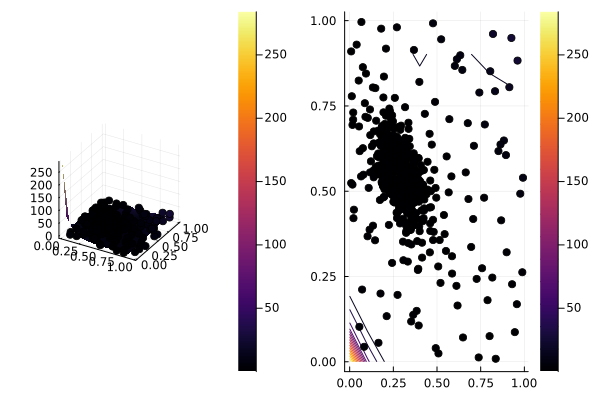

In [17]:
# The surrogate is queried with a tuple of parameters (a 1x3 matrix gives wrong values with RadialBasis)
p1 = plot(collect(lower_bound[2]:0.1:upper_bound[2]), collect(lower_bound[3]:0.1:upper_bound[3]), (x, y) -> exp(surrogate((alpha0, x, y))), linetype=:surface)
beta1s = [xy[2] for xy in xys]
beta2s = [xy[3] for xy in xys]
g_alpha0(x) = g([alpha0; x[2]; x[3]]) #objective, holding alpha at its true value
zs_alpha0 = g_alpha0.(xys)
scatter!(beta1s, beta2s, zs_alpha0, marker_z=zs_alpha0, label="")
p2 = contour(collect(lower_bound[2]:0.1:upper_bound[2]), collect(lower_bound[3]:0.1:upper_bound[3]), (x, y) -> exp(surrogate((alpha0, x, y))))
scatter!(beta1s, beta2s, marker_z=zs_alpha0, label="")
plot(p1, p2) 

Let's plot the objective function, **holding constant the value of $\beta_2$**:

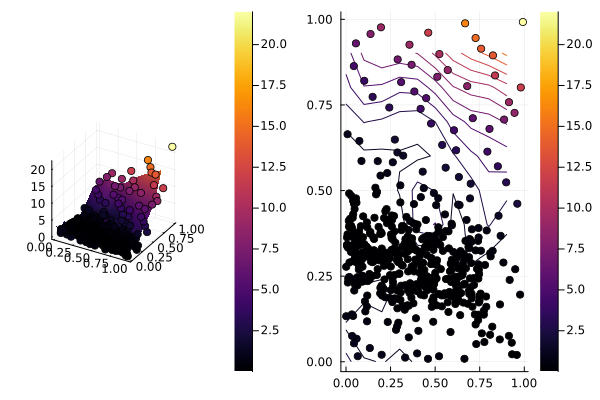

In [18]:
# The surrogate is queried with a tuple of parameters (a 1x3 matrix gives wrong values with RadialBasis)
p1 = plot(collect(lower_bound[1]:0.1:upper_bound[1]), collect(lower_bound[2]:0.1:upper_bound[2]), (x, y) -> exp(surrogate((x, y, beta0[2]))), linetype=:surface)
alphas = [xy[1] for xy in xys]
beta1s = [xy[2] for xy in xys]
g_beta2(x) = g([x[1]; x[2]; beta0[2]]) #objective, holding beta2 at its true value
zs_beta2 = g_beta2.(xys)
scatter!(alphas, beta1s, zs_beta2, marker_z=zs_beta2, label="")
p2 = contour(collect(lower_bound[1]:0.1:upper_bound[1]), collect(lower_bound[2]:0.1:upper_bound[2]), (x, y) -> exp(surrogate((x, y, beta0[2]))))
scatter!(alphas, beta1s, marker_z=zs_beta2, label="")
plot(p1, p2)

### Explore the sampling process

**Top:** the objective function at each evaluated point, in the order of evaluation (log scale). The initial design (Sobol, gray) spreads over the whole parameter space. The points added by the parallel batches (blue, light = early, dark = late) concentrate where the objective function is low, and the best point improves step by step. The local refinement then finds the minimum (dashed line).

**Bottom:** where the points were evaluated, in the three pairwise projections of the parameter space. The added points concentrate in a band where $\beta_1$ and $\beta_2$ fit the moments, but remain spread out along $\alpha$: the intercept is the parameter the moments identify least precisely. The MSM estimate (◆) differs from the true values (×) because of sampling and simulation noise.

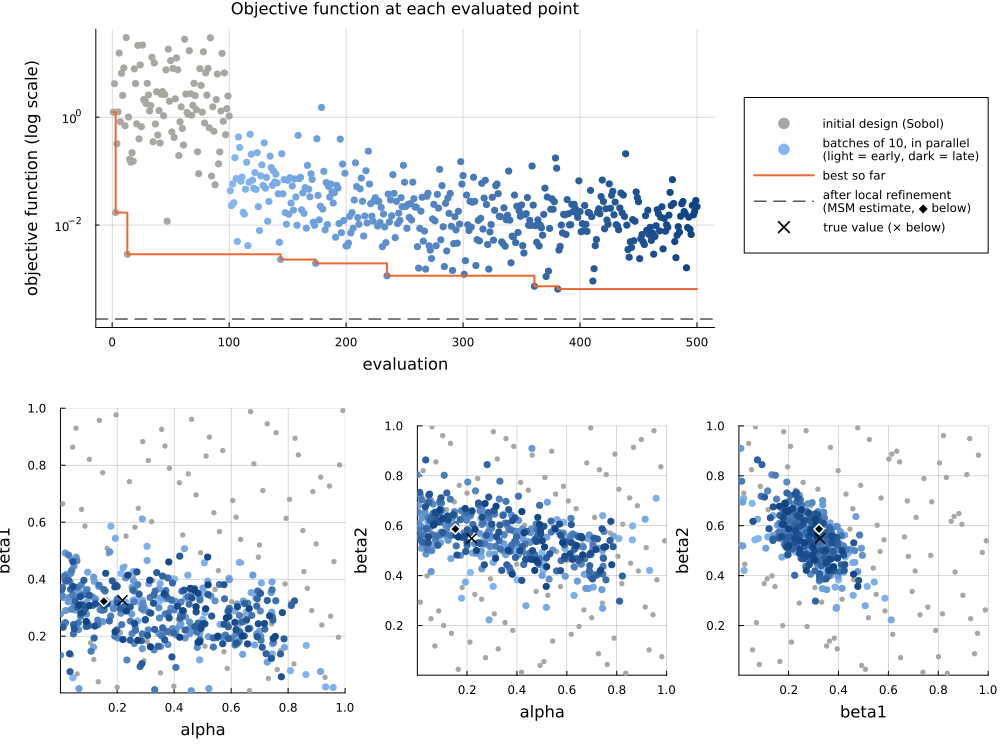

In [19]:
# History of the surrogate optimization: every evaluated point, in evaluation order
#----------------------------------------------------------------------------------
samples = surrogate.x      # the initial design, then the points added by the batches
objectiveValues  = exp.(surrogate.y) # objective function at these points (the surrogate stores its log)
nInitial = n_samples
added = (nInitial + 1):length(samples)

colorInitial = "#a8a7a2"                        # neutral gray: context
colorBest    = "#eb6834"                        # orange: best value so far
rampAdded    = cgrad(["#86b6ef", "#104281"])    # one hue (blue): light = early, dark = late

# (1) Convergence: objective function at each evaluation (log scale)
bestSoFar = accumulate(min, objectiveValues)
p_conv = scatter(1:nInitial, objectiveValues[1:nInitial], color = colorInitial, markersize = 4, markerstrokewidth = 0,
                 label = "initial design (Sobol)")
scatter!(p_conv, added, objectiveValues[added], marker_z = collect(added), color = rampAdded, colorbar = false,
         markersize = 4, markerstrokewidth = 0, label = "batches of $(batchSize), in parallel\n(light = early, dark = late)")
plot!(p_conv, 1:length(objectiveValues), bestSoFar, seriestype = :steppost, color = colorBest, linewidth = 2,
      label = "best so far")
hline!(p_conv, [Optim.minimum(localResults)], color = :black, linestyle = :dash, linewidth = 1,
       label = "after local refinement\n(MSM estimate, ◆ below)")
scatter!(p_conv, [NaN], [NaN], color = :black, marker = :xcross, markersize = 5, label = "true value (× below)")
plot!(p_conv, yscale = :log10, xlabel = "evaluation", ylabel = "objective function (log scale)",
      title = "Objective function at each evaluated point", titlefontsize = 11,
      legend = :outerright, legendfontsize = 8, gridalpha = 0.3, left_margin = 8Plots.mm, bottom_margin = 4Plots.mm)

# (2) Where the points were evaluated: pairwise projections of the parameter space
paramNames = ["alpha", "beta1", "beta2"]
estimate = Optim.minimizer(localResults)
trueValues = [alpha0; beta0]
panels = []
for (i, j) in [(1, 2), (1, 3), (2, 3)]
    p = scatter([s[i] for s in samples[1:nInitial]], [s[j] for s in samples[1:nInitial]],
                color = colorInitial, markersize = 3, markerstrokewidth = 0)
    scatter!(p, [samples[t][i] for t in added], [samples[t][j] for t in added], marker_z = collect(added),
             color = rampAdded, colorbar = false, markersize = 4, markerstrokewidth = 0)
    scatter!(p, [estimate[i]], [estimate[j]], color = :black, marker = :diamond, markersize = 5,
             markerstrokecolor = :white, markerstrokewidth = 1)
    scatter!(p, [trueValues[i]], [trueValues[j]], color = :black, marker = :xcross, markersize = 5,
             markerstrokecolor = :white, markerstrokewidth = 1)
    plot!(p, xlabel = paramNames[i], ylabel = paramNames[j], xlims = (lower_bound[i], upper_bound[i]),
          ylims = (lower_bound[j], upper_bound[j]), aspect_ratio = :equal, gridalpha = 0.3, legend = false)
    push!(panels, p)
end
history = plot(p_conv, panels..., layout = @layout([a; b c d]), size = (1000, 750))
history

---

## Handling failures of the objective function

In real-world applications, the *objective function may fail*: no convergence, or a run stopped because it is too slow or stuck. MethodOfSimulatedMoments.jl then returns a penalty value (`penaltyValue`). Feeding this value to the surrogate "pollutes" it: on the log scale used here, successful runs lie roughly between −8 and 3, while log(`penaltyValue`) ≈ 13.8, and the surrogate must pass through this spike, which distorts it over a wide area.

This section compares three ways of handling failures:

* **baseline**: as above, failures enter the surrogate with the penalty value;
* **imputation**: failures enter the surrogate with the worst successful value observed so far (Forrester, Sóbester and Keane, 2006, *Optimization with missing data*);
* **penalized**: the surrogate $\hat{f}$ is built on successful runs only, and new points minimize:

$$A(\theta) = \hat{f}(\theta) + \lambda_t \, \big(1 - p_{success}(\theta)\big),$$

where $p_{success}(\theta)$ is the probability that the model converges at $\theta$, estimated by a classifier on all evaluated points (successes and failures), and $\lambda_t$ is the cost of a failure, in the units of $\hat{f}$. Since $A(\theta) = p_{success} \, \hat{f} + (1 - p_{success}) \, (\hat{f} + \lambda_t)$, $A$ is the expected value of the objective function when a failure costs $\lambda_t$ more. For now, $\lambda_t = \lambda_0$ = `penalty_multiplier` × (range of the successful values).

The estimation loop of the penalized approach:

1. evaluate the initial design in parallel, keeping the values **and** the successes/failures;
2. fit the surrogate $\hat{f}$ on successes only;
3. fit the classifier on successes/failures;
4. compute $\lambda_0$;
5. propose a batch of new points with SRBF on $A(\theta)$ (through a wrapper, `PenalizedSurrogate`, whose value is $A(\theta)$);
6. evaluate the batch in parallel; update $\hat{f}$ with the successes, refit the classifier on all points, and go back to step 5.

Two classifiers are available (`classifierType`):

* `:Lasso`: penalized logistic regression ([Lasso.jl](https://github.com/JuliaStats/Lasso.jl)) on Gaussian bumps centered at the evaluated points (a linear or quadratic logit cannot learn a small failure region);
* `:GaussianProcess`: Gaussian-process classifier. It is cautious where it has no data: there, its probability of success is closer to the average, which discourages exploring unknown regions.

To illustrate, the model fails with probability `failureProbInside` in a disk of the $(\beta_1, \beta_2)$ plane next to the MSM estimate, and with probability `failureProbOutside` elsewhere. In this section, new points are always proposed with SRBF (the wrapper provides no uncertainty, so `EI()` cannot be used); the surrogate is the one chosen with `surrogateType`.

**References**
* Forrester, Alexander IJ, András Sóbester, and Andy J. Keane. "Optimizaiton with Missing Data." Proceedings: Mathematical, Physical and Engineering Sciences (2006): 935-945.

In [20]:
# Failure model: in a disk of the (beta1, beta2) plane, the model fails with probability
# failureProbInside; outside, with probability failureProbOutside
#-----------------------------------------------------------------------------------------
failureCenter = (0.40, 0.45)    # (beta1, beta2), next to the MSM estimate but not covering it
failureRadius = 0.12
failureProbInside = 0.9
failureProbOutside = 0.0
@everywhere failureCenter = $failureCenter
@everywhere failureRadius = $failureRadius
@everywhere failureProbInside = $failureProbInside
@everywhere failureProbOutside = $failureProbOutside

# The failure is drawn from a random generator seeded by the parameter values:
# the same θ gives the same outcome, on any worker and in any run
@everywhere function simulated_failure(θ)
    inside = (θ[2] - failureCenter[1])^2 + (θ[3] - failureCenter[2])^2 < failureRadius^2
    u = rand(MersenneTwister(hash(Tuple(Float64.(collect(θ))))))
    return u < (inside ? failureProbInside : failureProbOutside)
end

# The failure is raised inside the simulation: MethodOfSimulatedMoments.jl then returns the penalty value,
# as for a real failure (no convergence, error...)
@everywhere set_simulate_empirical_moments!(myProblem, x -> (simulated_failure(x) && error("simulated failure");
                                                             functionLinearModel(x, gaussian_draws = gaussian_draws, simX = simX, burnInPerc = burnInPerc)))
@everywhere construct_objective_function!(myProblem)
@everywhere using Logging
@everywhere disable_logging(Logging.Info)   #MethodOfSimulatedMoments.jl logs every failure

# One evaluation: log(objective function), and whether the model converged
@everywhere function evaluate_point(θ)
    sleep(modelCost)
    value = myProblem.objective_function(collect(θ))
    return (log(value), value != myProblem.options.penaltyValue)
end

In [21]:
# Classifiers of success/failure: p_success(classifier, θ) = probability that the model converges at θ
#---------------------------------------------------------------------------------------------------
using Lasso
classifierType = :Lasso         # :Lasso or :GaussianProcess

# Parameters rescaled to [0, 1] (one row per point)
scaled(θ) = (collect(θ) .- lower_bound) ./ (upper_bound .- lower_bound)
scaled_matrix(points) = permutedims(reduce(hcat, [scaled(p) for p in points]))
logistic(z) = 1 / (1 + exp(-z))

# (a) Penalized logistic regression (Lasso.jl) on Gaussian bumps centred at the evaluated points
#     (a linear or quadratic logit cannot learn a small failure region)
bumpWidth = 0.05          #in units of each parameter's range
classifierλ = 1e-3        #penalty
classifierα = 0.0         #0: ridge, 1: lasso
bumps(Θ, centers) = [exp(-sum(abs2, Θ[i, :] .- centers[k, :]) / (2 * bumpWidth^2)) for i in 1:size(Θ, 1), k in 1:size(centers, 1)]
struct LassoClassifier
    model
    centers::Matrix{Float64}
end
function fit_lasso_classifier(Θ, successes)
    # The logistic fit can diverge when successes and failures are (almost) separated:
    # retry with a stronger penalty
    for λ in (classifierλ, 10 * classifierλ, 100 * classifierλ)
        try
            m = fit(LassoPath, bumps(Θ, Θ), Float64.(successes), Binomial(), LogitLink(); α = classifierα, λ = [λ])
            return LassoClassifier(m, Θ)
        catch
        end
    end
    return nothing
end
p_success(c::LassoClassifier, θ) = predict(c.model, bumps(permutedims(scaled(θ)), c.centers))[1]

# (b) Gaussian-process classifier: Laplace approximation (Rasmussen and Williams 2006, Gaussian Processes
#     for Machine Learning, algorithms 3.1 and 3.2).
#
#     Model: a latent function g(θ) ~ GP(m, K), and P(success | θ) = logistic(g(θ)).
#     * K: squared-exponential kernel, K(θ, θ') = gpVariance * exp(-|θ - θ'|² / (2 gpLengthScale²)):
#       the latent values of two points are strongly correlated when the points are close
#       (distance small compared to gpLengthScale)
#     * m: constant prior mean = logit of the observed success rate. Far from the data, the
#       classifier falls back to the observed success rate (with a zero mean, it would predict 0.5)
#     The posterior of g given the observed successes/failures is not Gaussian (the likelihood is
#     logistic). The Laplace approximation replaces it by a Gaussian centered at its mode, with
#     covariance given by the curvature at the mode.
gpLengthScale = 0.1       #in units of each parameter's range
gpVariance = 10.0         #prior variance of the latent function
se_kernel(A, B) = [gpVariance * exp(-sum(abs2, A[i, :] .- B[j, :]) / (2 * gpLengthScale^2)) for i in 1:size(A, 1), j in 1:size(B, 1)]
struct GPClassifier
    X::Matrix{Float64}          #training points (one per row, scaled to [0, 1])
    m::Float64                  #prior mean of the latent function
    grad::Vector{Float64}       #gradient of the log-likelihood at the mode: t - P(success)
    sW::Vector{Float64}         #sqrt(W), W = P(success) (1 - P(success)): curvature of the log-likelihood
    L::LowerTriangular{Float64, Matrix{Float64}}    #Cholesky factor of B = I + sqrt(W) K sqrt(W)
end

# Mode of the posterior of the latent function, by Newton's method (algorithm 3.1)
function fit_gp_classifier(Θ, successes; iterations = 50)
    n = size(Θ, 1)
    rate = clamp(mean(successes), 0.01, 0.99)     #observed success rate (kept away from 0 and 1)
    m = log(rate / (1 - rate))                    #prior mean: logit of the success rate
    t = Float64.(successes)                       #targets: 1 = success, 0 = failure
    K = se_kernel(Θ, Θ)                           #prior covariance of the latent values at the n points
    f = zeros(n)                                  #latent values minus the prior mean (start: the prior mean)
    for _ in 1:iterations
        prob = logistic.(m .+ f)                  #current probabilities of success
        # Log-likelihood sum(log P(t_i | g_i)): gradient t - prob, and curvature -W with
        # W = prob (1 - prob) (diagonal)
        W = prob .* (1 .- prob); sW = sqrt.(W)
        # Newton step f_new = (K^-1 + W)^-1 (W f + gradient), computed in the numerically stable
        # form of Rasmussen and Williams: only B = I + sqrt(W) K sqrt(W) is factorized (well
        # conditioned, eigenvalues >= 1), never K itself
        L = cholesky(Symmetric(I + sW .* K .* sW')).L
        b = W .* f .+ (t .- prob)
        fNew = K * (b .- sW .* (L' \ (L \ (sW .* (K * b)))))
        converged = maximum(abs.(fNew .- f)) < 1e-6
        f = fNew
        converged && break
    end
    # Quantities at the mode, kept for the predictions
    prob = logistic.(m .+ f); sW = sqrt.(prob .* (1 .- prob))
    return GPClassifier(Θ, m, t .- prob, sW, cholesky(Symmetric(I + sW .* K .* sW')).L)
end

# Probability of success at θ (algorithm 3.2)
function p_success(c::GPClassifier, θ)
    k = vec(se_kernel(permutedims(scaled(θ)), c.X))   #covariances between θ and the training points
    # Latent value at θ, under the Laplace approximation: Gaussian with
    # * mean m + k' (t - P(success)): close to the prior mean far from the data
    # * variance gpVariance - v'v: shrinks near the training points (gpVariance far from them)
    v = c.L \ (c.sW .* k)
    var_f = max(gpVariance - dot(v, v), 0.0)
    # P(success) = E[logistic(latent value)], approximated by logistic(mean / sqrt(1 + π var / 8))
    # (probit approximation, MacKay 1992; π = 3.14159...). A large variance pulls the probability
    # towards 0.5: this is why the classifier is cautious where it has no data
    return logistic((c.m + dot(k, c.grad)) / sqrt(1 + π * var_f / 8))
end

# Constant classifier, when only successes (or only failures) have been observed
struct ConstantClassifier
    p::Float64
end
p_success(c::ConstantClassifier, θ) = c.p

# Fit the chosen classifier; keep the previous one if the fit fails
function fit_classifier(points, successes; previous = nothing)
    (all(successes) || !any(successes)) && return ConstantClassifier(mean(successes))
    Θ = scaled_matrix(points)
    c = classifierType == :GaussianProcess ? fit_gp_classifier(Θ, successes) : fit_lasso_classifier(Θ, successes)
    return c === nothing ? something(previous, ConstantClassifier(mean(successes))) : c
end

fit_classifier (generic function with 1 method)

In [22]:
# Penalized objective A(θ) = f̂(θ) + λ_t * (1 - p_success(θ))
#-------------------------------------------------------------
# λ_t: cost of a failure, in the units of f̂ (log(objective function)). For now, constant:
# penalty_multiplier times the range of the successful values (a time-varying λ_t only
# requires changing this function)
penalty_multiplier = 1.0
lambda_t(batch, logValuesSuccess) = penalty_multiplier * max(maximum(logValuesSuccess) - minimum(logValuesSuccess), 1e-8)

# Wrapper: a surrogate whose value IS A(θ), so that Surrogates.jl's SRBF proposes new points
# from A. It needs the evaluated points x (successes AND failures: SRBF keeps its distance to
# them), the values y of A at these points, and update! for the virtual points of the constant liar
const SB = Surrogates.SurrogatesBase
mutable struct PenalizedSurrogate{S, C} <: SB.AbstractDeterministicSurrogate
    fhat::S                 #surrogate of log(objective function), on successes only
    classifier::C
    λ::Float64
    x::Vector
    y::Vector{Float64}
    lb::Vector{Float64}
    ub::Vector{Float64}
end
(s::PenalizedSurrogate)(θ) = s.fhat(θ) + s.λ * (1 - p_success(s.classifier, θ))
function PenalizedSurrogate(fhat, classifier, λ, points)
    s = PenalizedSurrogate(fhat, classifier, λ, copy(points), Float64[], lower_bound, upper_bound)
    s.y = [s(θ) for θ in s.x]
    return s
end
function SB.update!(s::PenalizedSurrogate, new_x, new_y)
    #virtual point of the constant liar: added to f̂, converted from the units of A to those of f̂
    SB.update!(s.fhat, [new_x], [new_y - s.λ * (1 - p_success(s.classifier, new_x))])
    push!(s.x, new_x); push!(s.y, new_y)
    return s
end

# Surrogate chosen with surrogateType (see "Building a surrogate")
build_surrogate(x, y) = surrogateType == :RadialBasis ?
    RadialBasis(copy(x), copy(y), lower_bound, upper_bound, rad = cubicRadial()) :
    Kriging(copy(x), copy(y), lower_bound, upper_bound, p = collect([1.5 for k in 1:length(dictPriors)]))

build_surrogate (generic function with 1 method)

In [23]:
# Three ways of handling failures, with the same initial design, batches and budget
#-----------------------------------------------------------------------------------
# * :baseline   : failures enter the surrogate with the penalty value
# * :imputation : failures enter the surrogate with the worst successful value so far
# * :penalized  : the surrogate f̂ uses successes only; new points minimize A(θ)
# live = true redraws the history after each batch (see plot_history above), with label in the title
function run_approach(approach, initialPoints, initialResults; seed = 1234, live = false, label = string(approach))
    Random.seed!(seed)
    X = copy(initialPoints)
    Y = first.(initialResults)       #log(objective function), log(penalty value) if failure
    S = last.(initialResults)        #success?
    imputed(y, s) = s ? y : maximum(Y[S])
    classifier = nothing
    if approach == :penalized
        surrogate = build_surrogate(X[S], Y[S])
        classifier = fit_classifier(X, S)
    else
        surrogate = build_surrogate(X, approach == :imputation ? imputed.(Y, S) : Y)
    end
    for batch in 1:maxBatches
        proposer = approach == :penalized ? PenalizedSurrogate(surrogate, classifier, lambda_t(batch, Y[S]), X) : surrogate
        newPoints, _ = potential_optimal_points(SRBF(), MeanConstantLiar(), lower_bound, upper_bound,
                                                proposer, RandomSample(), batchSize)
        results = pmap(evaluate_point, newPoints)          #batchSize evaluations, in parallel
        newY, newS = first.(results), last.(results)
        if approach == :penalized
            any(newS) && update!(surrogate, newPoints[newS], newY[newS])
        else
            update!(surrogate, newPoints, approach == :imputation ? imputed.(newY, newS) : newY)
        end
        append!(X, newPoints); append!(Y, newY); append!(S, newS)
        approach == :penalized && (classifier = fit_classifier(X, S, previous = classifier))
        if live == true
            show_live(plot_history(X, exp.(Y), length(initialPoints), successes = S, paramNames = collect(keys(dictPriors)),
                                   lower = lower_bound, upper = upper_bound, trueValues = true_vals,
                                   nbEvaluations = length(initialPoints) + maxBatches*batchSize,
                                   title = "$(label), seed $(seed), batch $(batch)/$(maxBatches): $(count(.!S)) failure(s)"))
        end
    end
    return (X = X, Y = Y, S = S, classifier = classifier)   #classifier: final one (penalized), or nothing
end

run_approach (generic function with 1 method)

In [24]:
# Comparison: same initial design, same batches and budget, several seeds
#--------------------------------------------------------------------------
batchSize = nworkers()
maxBatches = 20
seeds = [1234, 1, 2]
# A fresh Sobol design (xys has been extended by the surrogate optimization above)
initialPoints = Surrogates.sample(n_samples, lower_bound, upper_bound, SobolSample())
initialResults = pmap(evaluate_point, initialPoints)
println("Initial design: $(length(initialPoints)) points, $(count(!last, initialResults)) failures")

variants = [("baseline", :baseline, :Lasso), ("imputation", :imputation, :Lasso),
            ("penalized, Lasso", :penalized, :Lasso), ("penalized, GP", :penalized, :GaussianProcess)]
runs = Dict()
estimates = Dict()     #MSM estimate of each approach, after the local refinement
@time for (label, approach, ctype) in variants, seed in seeds
    global classifierType = ctype
    runs[(label, seed)] = run_approach(approach, initialPoints, initialResults, seed = seed, live = false, label = label)
end

# Summary: best successful value before the local refinement and number of failures (means over
# the seeds), and the result of the parallel local refinement (msm_multistart!, started from the
# nworkers() best successful points of the first seed)
nNew = maxBatches * batchSize
summary = DataFrame(approach = String[], best_before_refinement = Float64[], failures_out_of_new_points = Float64[],
                    after_multistart = Float64[])
for (label, _, _) in variants
    best = mean(exp(minimum(runs[(label, s)].Y[runs[(label, s)].S])) for s in seeds)
    failures = mean(count(.!runs[(label, s)].S[end-nNew+1:end]) for s in seeds)
    r = runs[(label, seeds[1])]
    order = sortperm([r.S[k] ? r.Y[k] : Inf for k in eachindex(r.Y)])[1:nworkers()]
    x0 = permutedims(reduce(hcat, [collect(r.X[k]) for k in order]))
    # check = false: the simulation fails (on purpose) at the initial values of the priors, which
    # lie in the failure region; msm_multistart! would otherwise stop with an error
    msm_multistart!(myProblem, x0 = x0, nums = nworkers(), verbose = false, check = false)
    estimates[label] = msm_multistart_minimizer(myProblem)
    push!(summary, (label, best, failures, msm_multistart_minimum(myProblem)))
end
println("$(nNew) new points per run, surrogate: $(surrogateType)")
summary

Initial design: 100 points, 4 failures
121.482676 seconds (2.40 G allocations: 77.756 GiB, 18.02% gc time, 1740 lock conflicts, 14.34% compilation time)
200 new points per run, surrogate: RadialBasis


Row,approach,best_before_refinement,failures_out_of_new_points,after_multistart
,String,Float64,Float64,Float64
1,baseline,0.00578012,0.666667,0.000180666
2,imputation,0.00298881,1.66667,0.000180669
3,"penalized, Lasso",0.00099595,15.0,0.000180665
4,"penalized, GP",0.00240584,3.33333,0.000180667


200 new points per run, surrogate: RadialBasis


Row,approach,best_before_refinement,failures_out_of_new_points,after_multistart
,String,Float64,Float64,Float64
1,baseline,0.00578012,0.666667,0.000180666
2,imputation,0.00298881,1.66667,0.000180669
3,"penalized, Lasso",0.00099595,15.0,0.000180665
4,"penalized, GP",0.00240584,3.33333,0.000180667


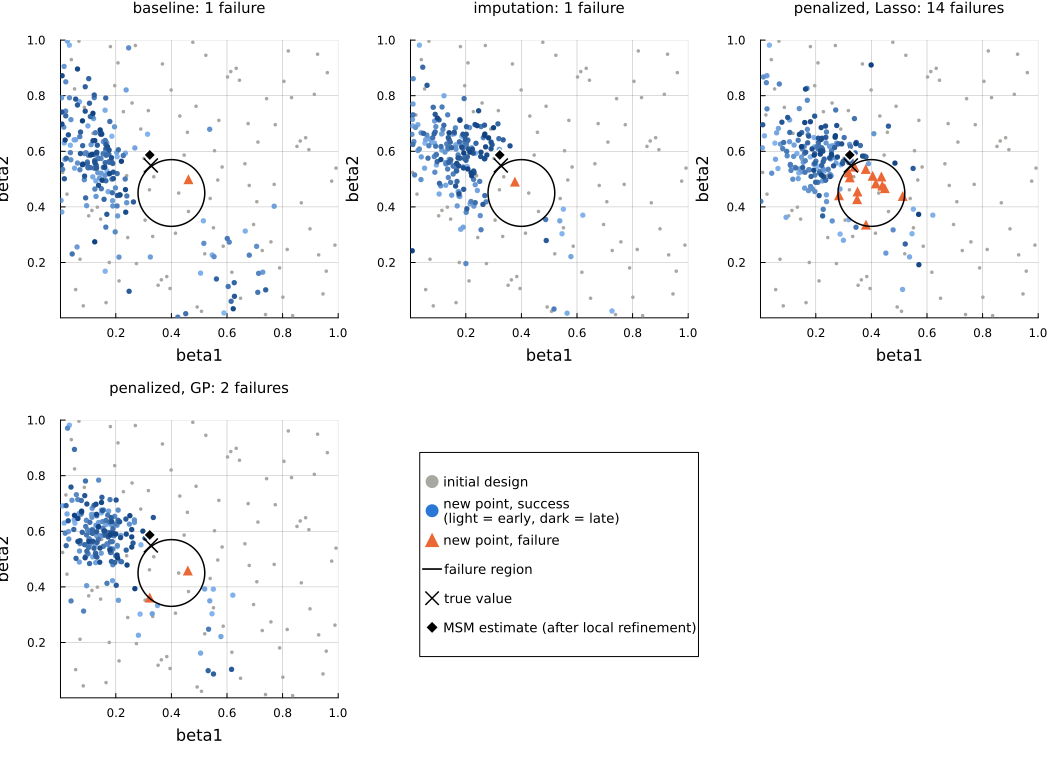

In [25]:
# Where each approach evaluated the objective function (first seed), in the (beta1, beta2) plane
#-----------------------------------------------------------------------------------------------
colorInitial = "#a8a7a2"      #neutral gray: initial design
colorSuccess = "#2a78d6"      #blue: new points, success
colorFailure = "#eb6834"      #orange: new points, failure
rampAdded = cgrad(["#86b6ef", "#104281"])    #one hue (blue): light = early, dark = late
trueValues = [alpha0; beta0]
circle = [(failureCenter[1] + failureRadius * cos(t), failureCenter[2] + failureRadius * sin(t)) for t in range(0, 2π, length = 200)]
failurePanels = []
for (k, (label, _, _)) in enumerate(variants)
    r = runs[(label, seeds[1])]
    added = (length(initialPoints) + 1):length(r.X)
    ok = [i for i in added if r.S[i]]
    ko = [i for i in added if !r.S[i]]
    p = scatter([θ[2] for θ in initialPoints], [θ[3] for θ in initialPoints], color = colorInitial,
                markersize = 2, markerstrokewidth = 0, label = "initial design")
    scatter!(p, [r.X[i][2] for i in ok], [r.X[i][3] for i in ok], marker_z = ok, color = rampAdded, colorbar = false,
             markersize = 3, markerstrokewidth = 0, label = "new point, success")
    scatter!(p, [r.X[i][2] for i in ko], [r.X[i][3] for i in ko], color = colorFailure, marker = :utriangle,
             markersize = 5, markerstrokewidth = 0, label = "new point, failure")
    plot!(p, first.(circle), last.(circle), color = :black, linewidth = 1.5, label = "failure region")
    scatter!(p, [trueValues[2]], [trueValues[3]], color = :black, marker = :xcross, markersize = 7, label = "true value")
    scatter!(p, [estimates[label][2]], [estimates[label][3]], color = :black, marker = :diamond, markersize = 6,
             markerstrokecolor = :white, markerstrokewidth = 1, label = "MSM estimate")
    plot!(p, title = "$(label): $(length(ko)) failure$(length(ko) == 1 ? "" : "s")", titlefontsize = 10, xlabel = "beta1", ylabel = "beta2",
          xlims = (lower_bound[2], upper_bound[2]), ylims = (lower_bound[3], upper_bound[3]), aspect_ratio = :equal,
          gridalpha = 0.3, legend = false)
    push!(failurePanels, p)
end
# Legend in its own panel
legendPanel = scatter([NaN], [NaN], color = colorInitial, markersize = 2, markerstrokewidth = 0, label = "initial design",
                      framestyle = :none, legend = :left, legendfontsize = 9)
scatter!(legendPanel, [NaN], [NaN], color = colorSuccess, markersize = 3, markerstrokewidth = 0,
         label = "new point, success\n(light = early, dark = late)")
scatter!(legendPanel, [NaN], [NaN], color = colorFailure, marker = :utriangle, markersize = 5, markerstrokewidth = 0,
         label = "new point, failure")
plot!(legendPanel, [NaN], [NaN], color = :black, linewidth = 1.5, label = "failure region")
scatter!(legendPanel, [NaN], [NaN], color = :black, marker = :xcross, markersize = 7, label = "true value")
scatter!(legendPanel, [NaN], [NaN], color = :black, marker = :diamond, markersize = 6, markerstrokecolor = :white,
         markerstrokewidth = 1, label = "MSM estimate (after local refinement)")
failureFigure = plot(failurePanels..., legendPanel, layout = @layout([a b c; d e _]), size = (1050, 760))
failureFigure

### History of the optimization with failures

The objective function at each evaluated point, in evaluation order (first seed), as in *Explore the sampling process* above. A failed run has no value (only the penalty value, far off the scale): failures are drawn as triangles on a line above the worst successful value, and the best value so far only counts successful runs. The y-axis is the same in all panels.

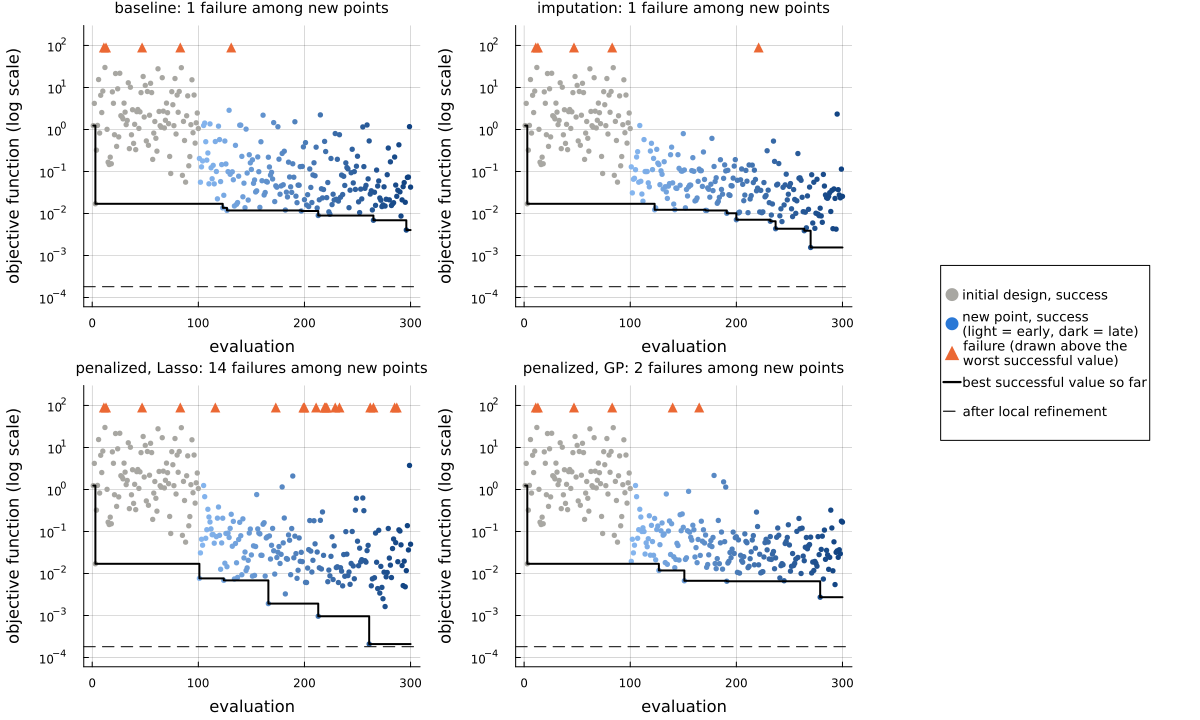

In [26]:
# History of the optimization with failures (first seed): objective function at each evaluated
# point, in evaluation order. Failures have no value (only the penalty value): they are shown as
# triangles on a line above the worst successful value of all runs
#------------------------------------------------------------------------------------------------
rampAdded = cgrad(["#86b6ef", "#104281"])    #one hue (blue): light = early, dark = late
nInitial = length(initialPoints)
worstSuccess = maximum(maximum(exp.(runs[(label, seeds[1])].Y[runs[(label, seeds[1])].S])) for (label, _, _) in variants)
failureLevel = 3 * worstSuccess              #where failures are drawn
yLimits = (minimum(summary.after_multistart) / 3, 10 * worstSuccess)
yTicks = 10.0 .^ (ceil(Int, log10(yLimits[1])):floor(Int, log10(yLimits[2])))

historyPanels = []
for (k, (label, _, _)) in enumerate(variants)
    r = runs[(label, seeds[1])]
    values = exp.(r.Y)
    evaluations = 1:length(values)
    initialOK = [i for i in 1:nInitial if r.S[i]]
    addedOK = [i for i in (nInitial + 1):length(values) if r.S[i]]
    failures = [i for i in evaluations if !r.S[i]]
    newFailures = count(>(nInitial), failures)
    bestSoFar = accumulate(min, [r.S[i] ? values[i] : Inf for i in evaluations])
    bestSoFar[isinf.(bestSoFar)] .= NaN      #before the first success
    p = scatter(initialOK, values[initialOK], color = colorInitial, markersize = 3, markerstrokewidth = 0)
    scatter!(p, addedOK, values[addedOK], marker_z = addedOK, color = rampAdded, colorbar = false,
             markersize = 3, markerstrokewidth = 0)
    scatter!(p, failures, fill(failureLevel, length(failures)), color = colorFailure, marker = :utriangle,
             markersize = 5, markerstrokewidth = 0)
    plot!(p, evaluations, bestSoFar, seriestype = :steppost, color = :black, linewidth = 2)
    hline!(p, [summary.after_multistart[k]], color = :black, linestyle = :dash, linewidth = 1)
    plot!(p, yscale = :log10, ylims = yLimits, yticks = yTicks, legend = false, gridalpha = 0.3,
          title = "$(label): $(newFailures) failure$(newFailures == 1 ? "" : "s") among new points", titlefontsize = 10,
          xlabel = "evaluation", ylabel = "objective function (log scale)")
    push!(historyPanels, p)
end
# Legend in its own panel
historyLegend = scatter([NaN], [NaN], color = colorInitial, markersize = 3, markerstrokewidth = 0,
                        label = "initial design, success", framestyle = :none, legend = :left, legendfontsize = 9)
scatter!(historyLegend, [NaN], [NaN], color = "#2a78d6", markersize = 3, markerstrokewidth = 0,
         label = "new point, success\n(light = early, dark = late)")
scatter!(historyLegend, [NaN], [NaN], color = colorFailure, marker = :utriangle, markersize = 5, markerstrokewidth = 0,
         label = "failure (drawn above the\nworst successful value)")
plot!(historyLegend, [NaN], [NaN], color = :black, linewidth = 2, label = "best successful value so far")
plot!(historyLegend, [NaN], [NaN], color = :black, linestyle = :dash, linewidth = 1, label = "after local refinement")
failureHistory = plot(historyPanels..., historyLegend, layout = @layout([grid(2, 2) a{0.25w}]), size = (1200, 720),
                      left_margin = 5Plots.mm, bottom_margin = 3Plots.mm)
failureHistory

### Probability of success implied by the classifiers

The probability of success $p_{success}(\theta)$ of the final classifier (first seed) of the two penalized approaches, in the $(\beta_1, \beta_2)$ plane, with $\alpha$ fixed at the MSM estimate of the approach. Dark blue: success likely; light blue: failure likely. Triangles: all failed evaluations (initial design included), from which the classifier learns. The Lasso classifier is confident: a sharp low-probability region where failures were observed, and a probability close to 1 elsewhere. The Gaussian-process classifier is cautious: a moderate probability everywhere, and a smoother dip around its (fewer) failures.

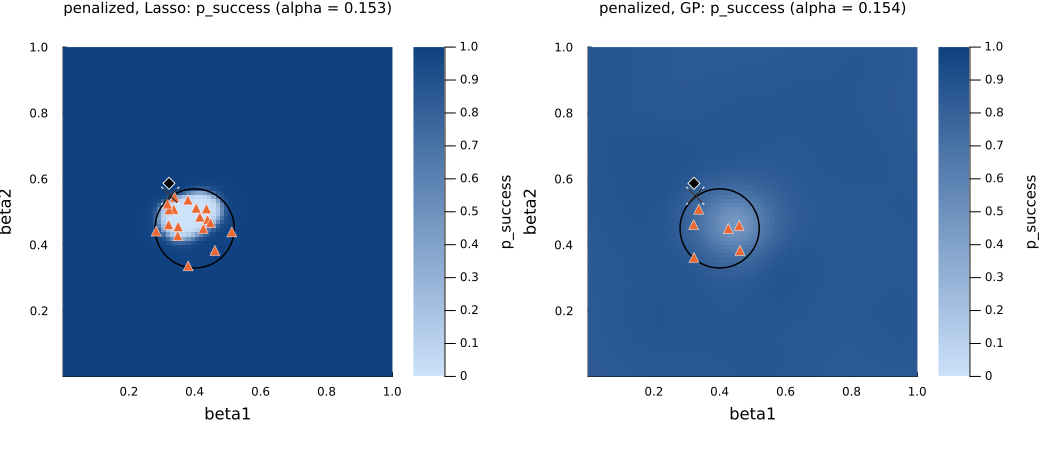

In [27]:
# Probability of success p_success(θ) implied by the final classifier (first seed), in the
# (beta1, beta2) plane, with alpha fixed at the MSM estimate of the approach
#-------------------------------------------------------------------------------------------
gridβ1 = range(lower_bound[2], upper_bound[2], length = 80)
gridβ2 = range(lower_bound[3], upper_bound[3], length = 80)
rampProbability = cgrad(["#cde2fb", "#104281"])    #one hue (blue): light = failure likely, dark = success likely
probabilityPanels = []
for (label, approach, _) in variants
    approach == :penalized || continue
    r = runs[(label, seeds[1])]
    α = estimates[label][1]
    P = [p_success(r.classifier, (α, b1, b2)) for b2 in gridβ2, b1 in gridβ1]    #rows: beta2, columns: beta1
    ko = [i for i in eachindex(r.X) if !r.S[i]]
    p = heatmap(gridβ1, gridβ2, P, color = rampProbability, clims = (0, 1), colorbar_title = "p_success")
    plot!(p, first.(circle), last.(circle), color = :black, linewidth = 1.5)
    scatter!(p, [r.X[i][2] for i in ko], [r.X[i][3] for i in ko], color = colorFailure, marker = :utriangle,
             markersize = 5, markerstrokecolor = :white, markerstrokewidth = 0.5)
    scatter!(p, [trueValues[2]], [trueValues[3]], color = :white, marker = :xcross, markersize = 9)   #white outline, visible on dark areas
    scatter!(p, [trueValues[2]], [trueValues[3]], color = :black, marker = :xcross, markersize = 7)
    scatter!(p, [estimates[label][2]], [estimates[label][3]], color = :black, marker = :diamond, markersize = 6,
             markerstrokecolor = :white, markerstrokewidth = 1)
    plot!(p, title = "$(label): p_success (alpha = $(round(α, digits = 3)))", titlefontsize = 10,
          xlabel = "beta1", ylabel = "beta2", xlims = extrema(gridβ1), ylims = extrema(gridβ2),
          aspect_ratio = :equal, legend = false)
    push!(probabilityPanels, p)
end
probabilityFigure = plot(probabilityPanels..., layout = (1, length(probabilityPanels)), size = (1050, 450),
                         left_margin = 3Plots.mm, bottom_margin = 4Plots.mm)
probabilityFigure

### Results

* The **penalized** approach keeps the surrogate clean. With the Lasso classifier, it finds the best points before the local refinement, but it evaluates more points in the failure region: the classifier learns failures only around points where failures have been observed, while SRBF keeps exploring.
* The **Gaussian-process classifier** is more cautious: far fewer failures, at the cost of less exploration.
* **Imputation** is a simple middle ground, without a classifier (hence, robust).
* The **baseline** avoids the failure region for the same reason its points are worse: the penalty spike distorts the surrogate over a wide area.

Based on these results, I would probably first go for the imputation method (no extra classifier needed!) and do a robustness test with a Lasso classifier.

In [28]:
versioninfo()

Julia Version 1.13.1
Commit 96ca370cf0e (2026-09-25 19:34 UTC)
Build Info:
  Official https://julialang.org release
Platform Info:
  OS: Linux (x86_64-linux-gnu)
  CPU: 24 × Intel(R) Core(TM) i7-14650HX
  WORD_SIZE: 64
  LLVM: libLLVM-20.1.8 (ORCJIT, raptorlake)
  GC: Built with stock GC
Threads: 1 default, 1 interactive, 1 GC (on 24 virtual cores)


Commit 96ca370cf0e (2026-09-25 19:34 UTC)
Build Info:
  Official https://julialang.org release
Platform Info:
  OS: Linux (x86_64-linux-gnu)
  CPU: 24 × Intel(R) Core(TM) i7-14650HX
  WORD_SIZE: 64
  LLVM: libLLVM-20.1.8 (ORCJIT, raptorlake)
  GC: Built with stock GC
Threads: 1 default, 1 interactive, 1 GC (on 24 virtual cores)
